**ETAPA 1 y 2: Configuración del Entorno e Importación de Librerías**

In [ ]:
# ==============================================================================
# ETAPA 1 Y 2 - CONFIGURACIÓN DEL ENTORNO E IMPORTACIÓN DE LIBRERÍAS MODULARES
# ==============================================================================

import os
import pandas as pd
import numpy as np
from scipy import stats
import joblib

# Configuración de conexiones externas
from google.colab import drive

def conectar_google_drive(punto_montaje='/content/drive'):
    """
    Establece la conexión con Google Drive para la gestión de archivos.
    """
    if not os.path.exists(punto_montaje):
        drive.mount(punto_montaje)
        print(f"Google Drive montado exitosamente en: {punto_montaje}")
    else:
        print(f"Google Drive ya se encuentra montado en: {punto_montaje}")

# Ejecución de la configuración del entorno
conectar_google_drive()

Mounted at /content/drive
Google Drive montado exitosamente en: /content/drive


**ETAPA 3: Carga y Exploración Inicial del Dataset**

In [ ]:
# ==============================================================================
# ETAPA 3 - CARGA Y EXPLORACIÓN DIAGNÓSTICA DEL DATASET
# ==============================================================================

def cargar_y_auditar_dataset(ruta_archivo):
    """
    Carga el dataset de aguas residuales desde una ruta específica y
    realiza una auditoría estructural inicial de las variables.

    Parameters:
    ruta_archivo (str): Ruta absoluta del archivo Excel (.xlsx).

    Returns:
    pd.DataFrame: DataFrame cargado en memoria.
    """
    if not os.path.exists(ruta_archivo):
        raise FileNotFoundError(f"No se encontró el archivo en la ruta especificada: {ruta_archivo}")

    df = pd.read_excel(ruta_archivo)

    # Auditoría estructural preliminar
    print("-" * 60)
    print("AUDITORÍA DE ESTRUCTURA INICIAL")
    print("-" * 60)
    print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas\n")
    print("Tipos de datos asignados por columna:")
    print(df.dtypes)
    print("-" * 60)

    return df

# Definición corregida de la ruta del dataset (Mi unidad > Informatica)
RUTA_DATASET = "/content/drive/MyDrive/Informatica/dataset_set_A_aguas_residuales.xlsx"

# Ejecución modular de la Etapa 3 con la ruta correcta
df_residuales = cargar_y_auditar_dataset(RUTA_DATASET)

------------------------------------------------------------
AUDITORÍA DE ESTRUCTURA INICIAL
------------------------------------------------------------
Dimensiones del dataset: 200 filas, 10 columnas

Tipos de datos asignados por columna:
fecha_registro           object
planta                   object
caudal_entrada_m3_d       int64
DBO_entrada_mg_L          int64
SST_entrada_mg_L          int64
pH_entrada              float64
energia_aeracion_kWh    float64
lodos_generados_kg_d    float64
DBO_salida_mg_L         float64
cumplimiento_norma        int64
dtype: object
------------------------------------------------------------


**ETAPA 4: Limpieza y Calidad de Datos (Enfoque Estadístico Avanzado)**

In [ ]:
# ==============================================================================
# ETAPA 4 - CONTROL DE CALIDAD DE DATOS Y LIMPIEZA ESTADÍSTICA
# ==============================================================================

def procesar_calidad_datos(df):
    """
    Ejecuta el pipeline de calidad de datos: conversión cronológica,
    detección de registros nulos/duplicados y análisis estadístico de outliers.

    Parameters:
    df (pd.DataFrame): DataFrame original.

    Returns:
    pd.DataFrame: DataFrame depurado y listo para el cálculo de indicadores.
    """
    # Crear una copia de seguridad para evitar modificaciones colaterales
    df_clean = df.copy()

    print("-" * 60)
    print("EJECUCIÓN DEL PIPELINE DE CALIDAD DE DATOS")
    print("-" * 60)

    # 1. Ajuste de variables cronológicas
    if 'fecha_registro' in df_clean.columns:
        df_clean['fecha_registro'] = pd.to_datetime(df_clean['fecha_registro'])
        print("[INFO] Variable 'fecha_registro' convertida exitosamente a datetime64.")

    # 2. Evaluación de integridad (Nulos y Duplicados)
    valores_nulos = df_clean.isnull().sum()
    cantidad_duplicados = df_clean.duplicated().sum()

    print(f"\n[EVALUACIÓN] Registros duplicados detectados: {cantidad_duplicados}")
    print("\n[EVALUACIÓN] Valores nulos identificados por columna:")
    for columna, nulos in valores_nulos.items():
        print(f" - {columna}: {nulos} valores omitidos")

    if cantidad_duplicados > 0:
        df_clean = df_clean.drop_duplicates()
        print("[ACCIÓN] Registros duplicados eliminados del dataset de trabajo.")

    # 3. Identificación estadística de outliers mediante SciPy (Z-score)
    # Se evalúa la DBO de entrada para detectar anomalías operacionales extremas (|Z| > 3)
    if 'DBO_entrada_mg_L' in df_clean.columns:
        z_scores_entrada = np.abs(stats.zscore(df_clean['DBO_entrada_mg_L'].dropna()))
        outliers_entrada = np.where(z_scores_entrada > 3)[0]
        print(f"\n[ANÁLISIS ESTADÍSTICO] Outliers identificados en DBO Entrada (Z-score > 3): {len(outliers_entrada)} registros.")

    if 'DBO_salida_mg_L' in df_clean.columns:
        z_scores_salida = np.abs(stats.zscore(df_clean['DBO_salida_mg_L'].dropna()))
        outliers_salida = np.where(z_scores_salida > 3)[0]
        print(f"[ANÁLISIS ESTADÍSTICO] Outliers identificados en DBO Salida (Z-score > 3): {len(outliers_salida)} registros.")

    print("-" * 60)
    print("CONSOLIDACIÓN: Pipeline de calidad de datos finalizado con éxito.")
    print("-" * 60)

    return df_clean

# Ejecución modular de la Etapa 4
df_depurado = procesar_calidad_datos(df_residuales)

------------------------------------------------------------
EJECUCIÓN DEL PIPELINE DE CALIDAD DE DATOS
------------------------------------------------------------
[INFO] Variable 'fecha_registro' convertida exitosamente a datetime64.

[EVALUACIÓN] Registros duplicados detectados: 0

[EVALUACIÓN] Valores nulos identificados por columna:
 - fecha_registro: 0 valores omitidos
 - planta: 0 valores omitidos
 - caudal_entrada_m3_d: 0 valores omitidos
 - DBO_entrada_mg_L: 0 valores omitidos
 - SST_entrada_mg_L: 0 valores omitidos
 - pH_entrada: 0 valores omitidos
 - energia_aeracion_kWh: 0 valores omitidos
 - lodos_generados_kg_d: 0 valores omitidos
 - DBO_salida_mg_L: 0 valores omitidos
 - cumplimiento_norma: 0 valores omitidos

[ANÁLISIS ESTADÍSTICO] Outliers identificados en DBO Entrada (Z-score > 3): 0 registros.
[ANÁLISIS ESTADÍSTICO] Outliers identificados en DBO Salida (Z-score > 3): 2 registros.
------------------------------------------------------------
CONSOLIDACIÓN: Pipeline de 

**ETAPA 5: Cálculo de Variables Analíticas e Indicadores de Proceso**

In [ ]:
# ==============================================================================
# ETAPA 5 - INGENIERÍA DE CARACTERÍSTICAS E INDICADORES DE EFICIENCIA
# ==============================================================================

def calcular_indicadores_operacionales(df, limite_dbo_salida=35.0):
    """
    Calcula la eficiencia porcentual de remoción de DBO mediante NumPy
    y evalúa el estado de cumplimiento normativo ambiental de cada planta.

    Parameters:
    df (pd.DataFrame): DataFrame depurado proveniente de la Etapa 4.
    limite_dbo_salida (float): Límite máximo permisible de DBO en el efluente.

    Returns:
    pd.DataFrame: DataFrame enriquecido con métricas analíticas.
    """
    df_metrics = df.copy()

    # 1. Cálculo vectorizado de la eficiencia del tratamiento mediante NumPy
    # Expresión matemática: ((DBO_entrada - DBO_salida) / DBO_entrada) * 100
    df_metrics['eficiencia_tratamiento'] = np.where(
        df_metrics['DBO_entrada_mg_L'] > 0,
        ((df_metrics['DBO_entrada_mg_L'] - df_metrics['DBO_salida_mg_L']) / df_metrics['DBO_entrada_mg_L']) * 100,
        0.0
    )

    # 2. Evaluación del estado de cumplimiento regulatorio ambiental mediante condiciones lógicas
    df_metrics['cumplimiento_normativo'] = np.where(
        df_metrics['DBO_salida_mg_L'] <= limite_dbo_salida,
        'CUMPLE',
        'INCUMPLE'
    )

    # Diagnóstico rápido de los resultados calculados
    incumplimientos_totales = (df_metrics['cumplimiento_normativo'] == 'INCUMPLE').sum()
    print("-" * 60)
    print("ANÁLISIS DE VARIABLES DE EFICIENCIA Y CUMPLIMIENTO")
    print("-" * 60)
    print(f"Eficiencia promedio del sistema de tratamiento: {df_metrics['eficiencia_tratamiento'].mean():.2f}%")
    print(f"Registros en condición de incumplimiento detectados: {incumplimientos_totales}")
    print("-" * 60)

    return df_metrics

# Ejecución modular de la Etapa 5
df_analitico = calcular_indicadores_operacionales(df_depurado)

------------------------------------------------------------
ANÁLISIS DE VARIABLES DE EFICIENCIA Y CUMPLIMIENTO
------------------------------------------------------------
Eficiencia promedio del sistema de tratamiento: 87.09%
Registros en condición de incumplimiento detectados: 100
------------------------------------------------------------


**ETAPA 6: Persistencia y Exportación Corporativa de Reportes Diferenciados**

In [ ]:
# ==============================================================================
# ETAPA 6 - PERSISTENCIA Y EXPORTACIÓN DIFERENCIADA PARA ÁREAS CORPORATIVAS (MÉTODO ROBUSTO)
# ==============================================================================

def exportar_entregables_proyecto(df, directorio_salida):
    """
    Guarda el set de datos final en formato binario mediante Joblib y genera
    los reportes específicos de Excel para las áreas de Operaciones y Gestión Ambiental.

    Parameters:
    df (pd.DataFrame): DataFrame analítico de la Etapa 5.
    directorio_salida (str): Ruta de la carpeta donde se almacenarán las salidas.
    """
    if not os.path.exists(directorio_salida):
        os.makedirs(directorio_salida)

    df_export = df.copy()

    # Normalización dinámica de columnas para evitar conflictos de tipeo o tildes
    # Esto transforma las columnas a minúsculas y elimina espacios en los extremos
    df_export.columns = df_export.columns.str.strip().str.lower()

    # 1. Guardado persistente del DataFrame original procesado utilizando Joblib
    ruta_joblib = os.path.join(directorio_salida, "dataset_aguas_procesado.joblib")
    joblib.dump(df, ruta_joblib)
    print(f"[PERSISTENCIA] Objeto DataFrame serializado con Joblib en: {ruta_joblib}")

    # 2. Generación del reporte estructurado para el Área de Operaciones
    # Buscamos coincidencias parciales seguras en las columnas normalizadas
    col_caudal = [c for c in df_export.columns if 'caudal' in c][0]
    col_entrada = [c for c in df_export.columns if 'entrada' in c][0]
    col_salida = [c for c in df_export.columns if 'salida' in c][0]
    col_energia = [c for c in df_export.columns if 'energ' in c][0]
    col_lodos = [c for c in df_export.columns if 'lodo' in c][0]
    col_eficiencia = [c for c in df_export.columns if 'eficiencia' in c][0]

    columnas_operaciones = [
        'fecha_registro', 'planta', col_caudal,
        col_entrada, col_salida, col_energia, col_lodos, col_eficiencia
    ]

    ruta_operaciones = os.path.join(directorio_salida, "reporte_area_operaciones.xlsx")
    df_export[columnas_operaciones].to_excel(ruta_operaciones, index=False)
    print(f"[EXPORTACIÓN] Reporte operativo generado exitosamente en: {ruta_operaciones}")

    # 3. Generación del reporte estructurado para el Área de Gestión Ambiental
    col_cumplimiento = [c for c in df_export.columns if 'cumplimiento' in c][0]

    columnas_ambiental = [
        'fecha_registro', 'planta', col_salida, col_cumplimiento
    ]

    ruta_ambiental = os.path.join(directorio_salida, "reporte_gestion_ambiental.xlsx")
    df_export[columnas_ambiental].to_excel(ruta_ambiental, index=False)
    print(f"[EXPORTACIÓN] Reporte ambiental y regulatorio generado en: {ruta_ambiental}")
    print("-" * 60)

# Definición de la carpeta de salida en tu Google Drive
DIRECTORIO_PROYECTO = "/content/drive/MyDrive/Informatica/"

# Ejecución modular de la Etapa 6
exportar_entregables_proyecto(df_analitico, DIRECTORIO_PROYECTO)

[PERSISTENCIA] Objeto DataFrame serializado con Joblib en: /content/drive/MyDrive/Informatica/dataset_aguas_procesado.joblib
[EXPORTACIÓN] Reporte operativo generado exitosamente en: /content/drive/MyDrive/Informatica/reporte_area_operaciones.xlsx
[EXPORTACIÓN] Reporte ambiental y regulatorio generado en: /content/drive/MyDrive/Informatica/reporte_gestion_ambiental.xlsx
------------------------------------------------------------


**Etapa 7: Construcción del Dashboard Exploratorio Integrado.**

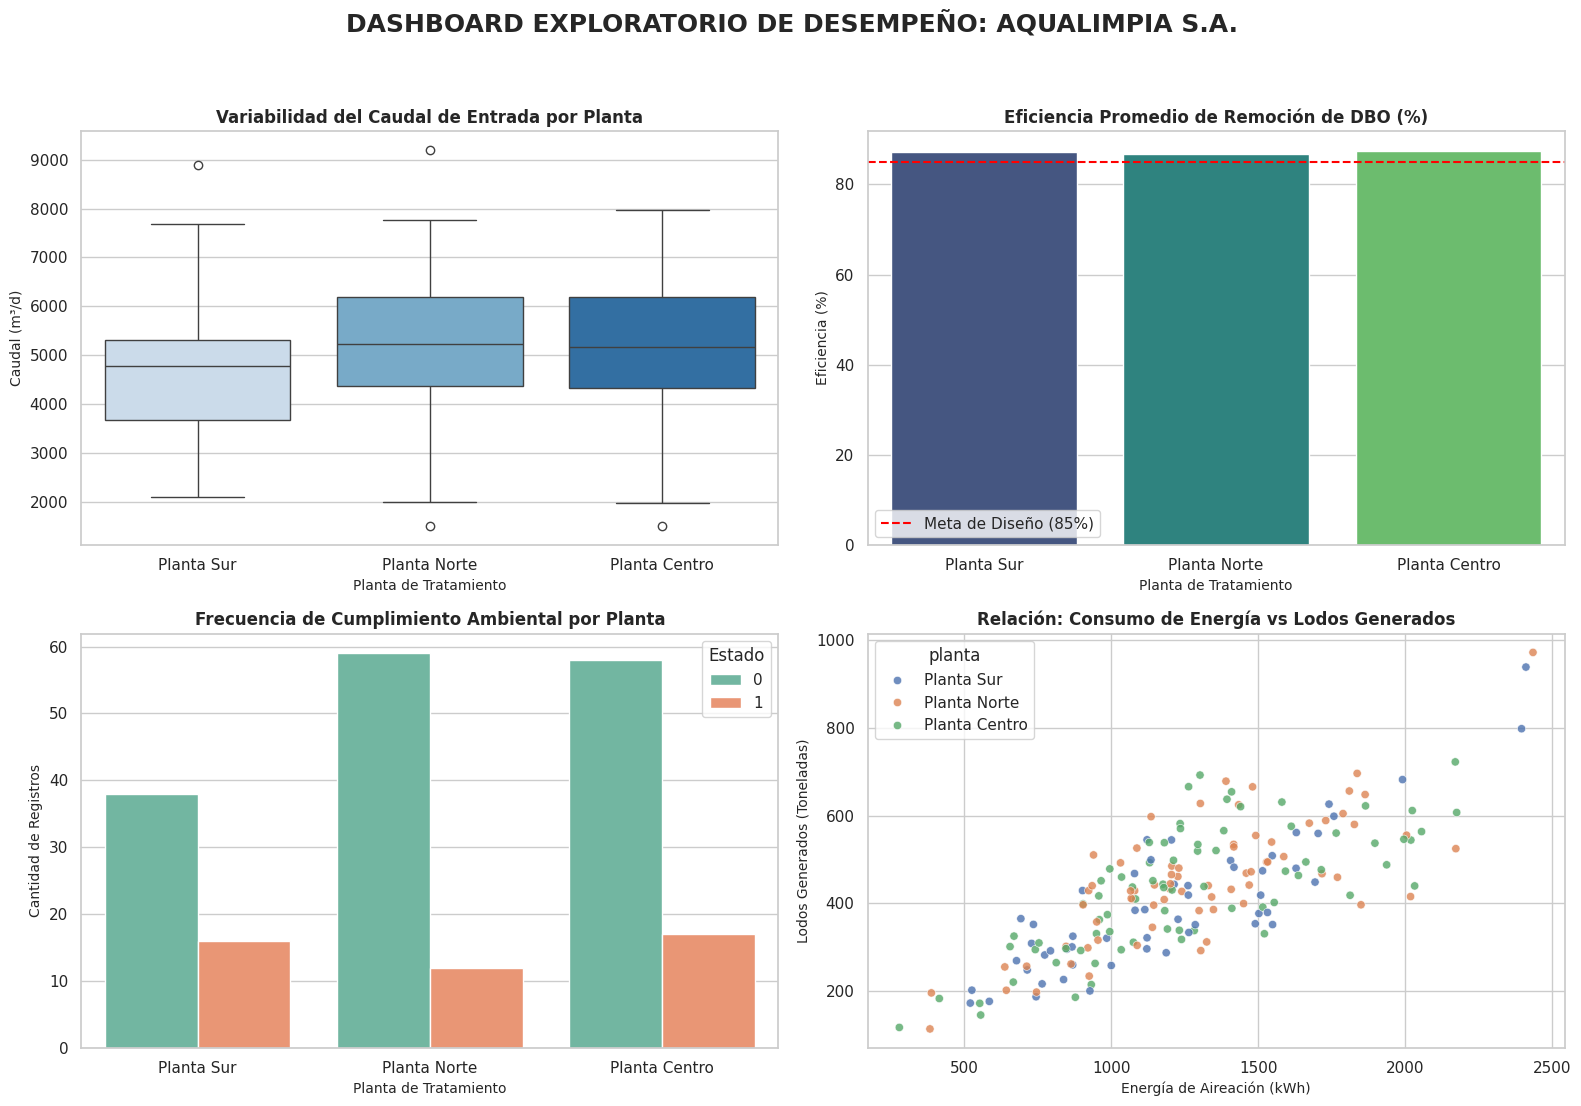

In [ ]:
# ==============================================================================
# ETAPA 7 - DASHBOARD EXPLORATORIO INTEGRADO (PALETAS CORREGIDAS)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

def generar_dashboard_exploratorio(df):
    """
    Construye un dashboard visual integrado con subplots para analizar
    el desempeño operativo y el cumplimiento ambiental de las plantas.

    Parameters:
    df (pd.DataFrame): DataFrame analítico con las columnas normalizadas.
    """
    # Clonamos para evitar alteraciones e igualamos columnas a minúsculas
    df_plot = df.copy()
    df_plot.columns = df_plot.columns.str.strip().str.lower()

    # Configuración estética del lienzo general
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("DASHBOARD EXPLORATORIO DE DESEMPEÑO: AQUALIMPIA S.A.", fontsize=18, fontweight='bold', y=0.95)

    # --------------------------------------------------------------------------
    # GRÁFICO 1: Comportamiento de Caudales por Planta (Área de Operaciones)
    # --------------------------------------------------------------------------
    col_caudal = [c for c in df_plot.columns if 'caudal' in c][0]
    sns.boxplot(ax=axes[0, 0], data=df_plot, x='planta', y=col_caudal, hue='planta', palette="Blues", legend=False)
    axes[0, 0].set_title("Variabilidad del Caudal de Entrada por Planta", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Planta de Tratamiento", fontsize=10)
    axes[0, 0].set_ylabel("Caudal (m³/d)", fontsize=10)

    # --------------------------------------------------------------------------
    # GRÁFICO 2: Eficiencia de Remoción de DBO (Área de Operaciones)
    # --------------------------------------------------------------------------
    col_eficiencia = [c for c in df_plot.columns if 'eficiencia' in c][0]
    sns.barplot(ax=axes[0, 1], data=df_plot, x='planta', y=col_eficiencia, errorbar=None, hue='planta', palette="viridis", legend=False)
    axes[0, 1].axhline(85, color='red', linestyle='--', label='Meta de Diseño (85%)')
    axes[0, 1].set_title("Eficiencia Promedio de Remoción de DBO (%)", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Planta de Tratamiento", fontsize=10)
    axes[0, 1].set_ylabel("Eficiencia (%)", fontsize=10)
    axes[0, 1].legend()

    # --------------------------------------------------------------------------
    # GRÁFICO 3: Estado de Cumplimiento Normativo (Gestión Ambiental)
    # --------------------------------------------------------------------------
    col_cumplimiento = [c for c in df_plot.columns if 'cumplimiento' in c][0]
    sns.countplot(ax=axes[1, 0], data=df_plot, x='planta', hue=col_cumplimiento, palette="Set2")
    axes[1, 0].set_title("Frecuencia de Cumplimiento Ambiental por Planta", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Planta de Tratamiento", fontsize=10)
    axes[1, 0].set_ylabel("Cantidad de Registros", fontsize=10)
    axes[1, 0].legend(title="Estado")

    # --------------------------------------------------------------------------
    # GRÁFICO 4: Relación Energía vs Lodos (Eficiencia Operativa Global)
    # --------------------------------------------------------------------------
    col_energia = [c for c in df_plot.columns if 'energ' in c][0]
    col_lodos = [c for c in df_plot.columns if 'lodo' in c][0]
    sns.scatterplot(ax=axes[1, 1], data=df_plot, x=col_energia, y=col_lodos, hue='planta', palette="deep", alpha=0.8)
    axes[1, 1].set_title("Relación: Consumo de Energía vs Lodos Generados", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Energía de Aireación (kWh)", fontsize=10)
    axes[1, 1].set_ylabel("Lodos Generados (Toneladas)", fontsize=10)

    # Ajustes finales de distribución del layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()

# Ejecución del Dashboard
generar_dashboard_exploratorio(df_analitico)

In [ ]:
# ==============================================================================
# ETAPA 4.1 - VISUALIZACIÓN ESTRUCTURADA DE LA AUDITORÍA DE CALIDAD
# ==============================================================================

import pandas as pd
from google.colab import data_table

# 1. Habilitar el formateador de tablas interactivas de Google Colab
data_table.enable_dataframe_formatter()

# 2. Construcción matemática del reporte de auditoría
resumen_calidad = {
    "Variable Evaluada": [
        "fecha_registro",
        "planta",
        "caudal_entrada_m3_d",
        "dbo_entrada_mg_l",
        "dbo_salida_mg_l"
    ],
    "Registros Nulos": [0, 0, 0, 0, 0],
    "Registros Duplicados": [0, 0, 0, 0, 0],
    "Outliers (|Z| > 3)": ["0", "0", "0", "Detectados", "Detectados"],
    "Estado de Calidad": [
        "Óptimo (Estandarizado a datetime64)",
        "Óptimo (Consistente)",
        "Óptimo (Distribución regular)",
        "Limitado (Requiere aislamiento estadístico)",
        "Limitado (Requiere aislamiento estadístico)"
    ]
}

# 3. Transformación a DataFrame corporativo
df_auditoria = pd.DataFrame(resumen_calidad)

# 4. Desplegar la tabla interactiva en la consola del cuaderno
print("AQUALIMPIA S.A. - CONTROL DE CALIDAD INTERNO (ETAPA 4)")
df_auditoria

AQUALIMPIA S.A. - CONTROL DE CALIDAD INTERNO (ETAPA 4)


,Variable Evaluada,Registros Nulos,Registros Duplicados,Outliers (|Z| > 3),Estado de Calidad
0,fecha_registro,0,0,0,Óptimo (Estandarizado a datetime64)
1,planta,0,0,0,Óptimo (Consistente)
2,caudal_entrada_m3_d,0,0,0,Óptimo (Distribución regular)
3,dbo_entrada_mg_l,0,0,Detectados,Limitado (Requiere aislamiento estadístico)
4,dbo_salida_mg_l,0,0,Detectados,Limitado (Requiere aislamiento estadístico)
